In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  ## better plots 
import sax  ## dizionario matrice scattering
from jax.typing import ArrayLike
import jax.numpy as jnp

In [36]:
## guida d'onda
from simphony.libraries import siepic 
wg1 = siepic.waveguide(length=2500, height=220) # length 2.5 mm
wg2 = siepic.waveguide(length=156.65, height=210) # length  mm

In [37]:
wg1
## fornisce il dizionario di parametri S della guida secondo la misura

{('o0', 'o0'): Array([0.+0.j], dtype=complex128),
 ('o0', 'o1'): Array([-0.82076344+0.57126822j], dtype=complex128),
 ('o1', 'o0'): Array([-0.82076344+0.57126822j], dtype=complex128),
 ('o1', 'o1'): Array([0.+0.j], dtype=complex128)}

In [38]:
wg2

{('o0', 'o0'): Array([0.+0.j], dtype=complex128),
 ('o0', 'o1'): Array([-0.10875718+0.99406835j], dtype=complex128),
 ('o1', 'o0'): Array([-0.10875718+0.99406835j], dtype=complex128),
 ('o1', 'o1'): Array([0.+0.j], dtype=complex128)}

**Example of definiton of a custom model with 2 ports and one parameter to run simulation on**

In [5]:
def par_model(param: float ) -> sax.SDict:
    ##This model will have one parameter, param, which defaults to 0.5.
    ## '->' typing che trasforma l'uscita in dizionario
    ## Args:
    ##      param: Some float parameter.
    ## Returns:
    ##    sdict: A dictionary of scattering matrices.
    
    # a simple wavelength independent s-matrix
    sdict = sax.reciprocal({
        ("in0", "out0"): -1j * np.sqrt(param) * np.pi,
    })
    ## fornisce una matrice di scattering da un singolo parametro
    return sdict

In [6]:
# A model is simulated by "calling" it with appropriate paraeters.
par_model(param=2.0)

{('in0', 'out0'): -4.442882938158366j, ('out0', 'in0'): -4.442882938158366j}

**il modello custom sarà utile per dare lo sfasamento dovuto a effetti dovuti alle interazioni col materiale della guida.**

__example of creation of a circuit(PIC)__
Ports are represented simply by string names in SAX, and a netlist (or a circuit) is simply a dictionary defining instances of models, their corresponding connections, and the subsequently exposed ports. 

In [7]:
from simphony.libraries import siepic
##The simplest way to create a circuit and connect ports is to define the keys ``"instances"``, ``"connections"``, and ``"ports"``, as follows:
netlist = {
    "instances": {
        "wg1":"waveguide",
        "wg2":"waveguide",
    },
    "connections": {
        "wg1,o1": "wg2,o0",
    },
    "ports": {
        "in": "wg1,o0", 
        "out": "wg2,o1",
    }
}


We need to tell the circuit what model use to calculate the s-parameters for the "waveguide" instances. We do this by passing in a dictionary of model names to model functions.

In [8]:
circuit, info = sax.circuit(
    netlist=netlist,
    models={
        "waveguide": siepic.waveguide,
    }
)


In [9]:
circuit?

Signature:
circuit(
    *,
    wg1={'wl': Array(1.55, dtype=float64), 'pol': 'te', 'length': Array(0., dtype=float64), 'width': Array(500., dtype=float64), 'height': Array(220., dtype=float64), 'loss': Array(0., dtype=float64)},
    wg2={'wl': Array(1.55, dtype=float64), 'pol': 'te', 'length': Array(0., dtype=float64), 'width': Array(500., dtype=float64), 'height': Array(220., dtype=float64), 'loss': Array(0., dtype=float64)},
) -> 'SType'
Docstring: <no docstring>
File:      ~/miniconda3/lib/python3.13/site-packages/sax/circuit.py
Type:      function

In [10]:
sdict = circuit(wl=np.linspace(1.5, 1.6, 5)) ## linspace fornisce valori equispaziati: inizio, fine, quantità di valori(>0) def.=50!
sdict
## valuta il circuito su un set di lungh d'onda

{('in',
  'in'): Array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j], dtype=complex128),
 ('in',
  'out'): Array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j], dtype=complex128),
 ('out',
  'in'): Array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j], dtype=complex128),
 ('out',
  'out'): Array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j], dtype=complex128)}

In [11]:
sdict[("in","out")] ## seleziona trasmissione in-out

Array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j], dtype=complex128)

In [12]:
from simphony.classical import ClassicalSim
##Let’s run a simple sweep simulation on the circuit we have created. 
##We can pass parameters to the individual components within our circuit using the names we gave them in our netlist–that is, “wg1” and “wg2”.

In [13]:

# Create a simulation and add a laser and detector
sim = ClassicalSim(circuit, wl=1.55, wg1={"length": 2500.0, "loss": 3.0}, wg2={"length": 7500.0, "loss": 3.0})
laser = sim.add_laser(ports=["in"], power=1.0)
detector = sim.add_detector(ports=["out"])

# Run the simulation
result = sim.run()

# Since the total wg length is 1 cm and the loss is 3 dB/cm, the power should be approximately 50%.
print(f"Power transmission: {abs(result.sdict['out'])**2}")


Power transmission: [0.50118723]


In [14]:
import gdsfactory as gf
gf.gpdk.PDK.activate()

In [15]:
# Create a new component
c = gf.Component()
# Add a rectangle
r = gf.components.rectangle(size=(10, 10), layer=(1, 0))
rect = c.add_ref(r)

In [16]:
# Show the result
c.show()

In [17]:

# Create a new component
c = gf.Component()

# Add a rectangle
r = gf.components.rectangle(size=(10, 10), layer=(1, 0))
rect = c.add_ref(r)

# Add text elements
t1 = gf.components.text("Hello", size=10, layer=(2, 0))
t2 = gf.components.text("world", size=10, layer=(2, 0))

text1 = c.add_ref(t1)
text2 = c.add_ref(t2)

# Position elements
text1.xmin = rect.xmax + 5
text2.xmin = text1.xmax + 2
text2.rotate(30)

# Show the result
c.show()

### Ora proviamo le guide della libreria ideal di simphony ###

In [18]:
from simphony.libraries import ideal

**Uso la guida d'onda "ideal" e trovo la caratteristica in merito allo sfasamento rispetto il "neff"**

In [19]:
wg_1 = ideal.waveguide(length = 150)
wg_2 = ideal.waveguide(length = 225)

In [20]:
S_par_wg1 = wg_1

In [21]:
print(S_par_wg1)

{('o0', 'o1'): Array(-0.95413926+0.29936312j, dtype=complex128), ('o1', 'o0'): Array(-0.95413926+0.29936312j, dtype=complex128)}


In [22]:
wg_2

{('o0', 'o1'): Array(-0.44039415-0.89780454j, dtype=complex128),
 ('o1', 'o0'): Array(-0.44039415-0.89780454j, dtype=complex128)}

**Confronto la trasmittanza tra le guide**

In [23]:
S_par_wg2 = wg_2

In [24]:
Pow_1 = jnp.abs(S_par_wg1["o0", "o1"])**2

In [25]:
Pow_1

Array(1., dtype=float64)

In [26]:
circuit_wg1, info = sax.circuit(
    netlist = {
        "instances": {
            "wg_1":"waveguide",
            "wg_2":"waveguide",
        },
        "connections": {
            "wg_1, o1":"wg_2, o0",
        },
        "ports": {
            "in0": "wg_1, o0",
            "out0": "wg_2, o1",
        },
    },
        models={
    "waveguide": ideal.waveguide,
}
)

In [43]:
sim1 = ClassicalSim(circuit_wg1, wl=np.linspace(1.5, 1.6, 150), wg_1={"length": 150.0}, wg_2={"length": 150.0})
laser = sim.add_laser(ports=['in0'], power= 1.0, phase=jnp.pi)
detector = sim.add_detector(ports=['out0'])

In [44]:
result = sim1.run()
result.detectors['out0'].plot()

KeyError: 'out0'

In [45]:
#lg = (22.5, 25, 50, 100, 125, 150, 170, 220, 250, 280, 300)
wl=np.linspace(1.5, 1.6, 150)

In [41]:
S_1 = circuit_wg1(wl=wl, wg_1={"length": 150.0}, wg_2={"length": 35.0})

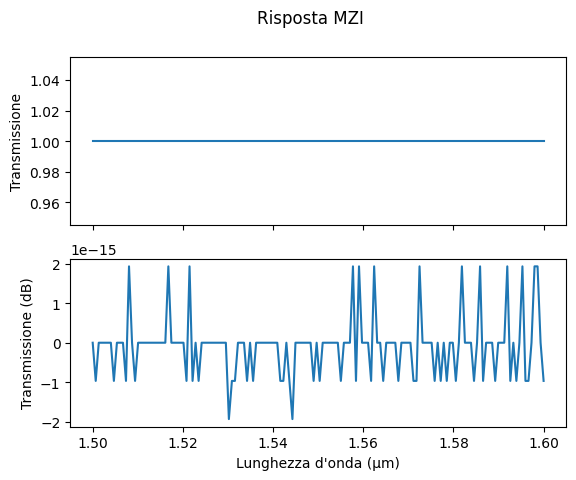

In [42]:
mag_1 = jnp.abs(S_1["out0", "in0"])**2 ## S_21

fig, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(wl, mag_1)
axs[0].set_ylabel("Transmissione")
axs[1].plot(wl, 10*jnp.log10(mag_1))
axs[1].set_ylabel("Transmissione (dB)")
axs[1].set_xlabel("Lunghezza d'onda (µm)")
plt.suptitle("Risposta MZI")
plt.show()

In [39]:
print(S_1)

{('in0', 'in0'): Array(0.+0.j, dtype=complex128), ('in0', 'out0'): Array(-0.25065253+0.96807712j, dtype=complex128), ('out0', 'in0'): Array(-0.25065253+0.96807712j, dtype=complex128), ('out0', 'out0'): Array(0.+0.j, dtype=complex128)}


In [46]:
print (phase)

NameError: name 'phase' is not defined